In [55]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [56]:
data_dict=pd.read_csv('data/data_dictionary.csv')
sessions = pd.read_csv("data/website_sessions.csv")
pageviews = pd.read_csv("data/website_pageviews.csv")
orders = pd.read_csv("data/orders.csv")
order_items = pd.read_csv("data/order_items.csv")
refunds = pd.read_csv("data/order_item_refunds.csv")
products = pd.read_csv("data/products.csv")

In [57]:
data_dict # this table gives the contents in each datasets


,Table,Field,Description
0,orders,order_id,Unique identifier for each order (PK)
1,orders,created_at,Timestamp when the order was placed
2,orders,website_session_id,Unique identifier for the website session (FK)
3,orders,user_id,Unique identifier for the user (FK)
4,orders,primary_product_id,Unique identifier for the primary product in t...
5,orders,items_purchased,Number of items in the order
6,orders,price_usd,Total price for the items in the order
7,orders,cogs_usd,Cost of goods sold for the items in the order
8,order_items,order_item_id,Unique identifier for each order item (PK)
9,order_items,created_at,Timestamp when the order was placed


In [58]:
products 

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [59]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [60]:
order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


## PRODUCT SALES VOLUME 

In [61]:
products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [62]:
product_sales = order_items.groupby('product_id')['order_item_id'].count().reset_index() 
product_sales.columns = ['product_id', 'Units_sold'] 

In [63]:
product_sales # total units sold per product


,product_id,Units_sold
0,1,24226
1,2,5796
2,3,4985
3,4,5018


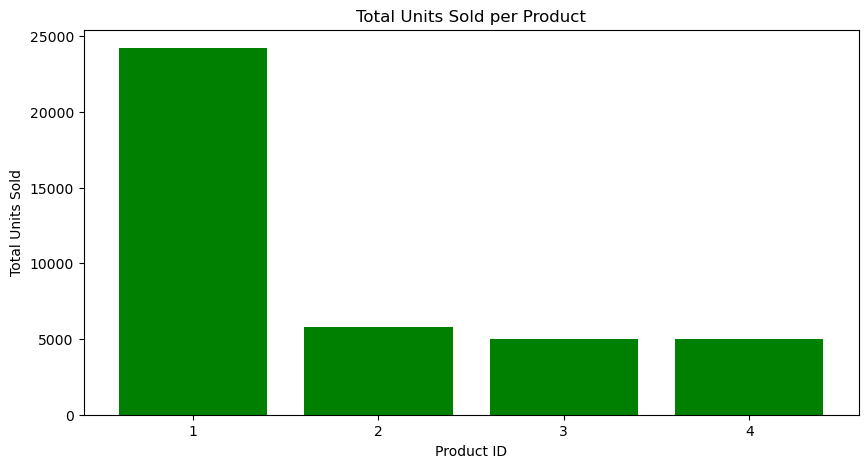

In [129]:
plt.figure(figsize=(10, 5))
plt.bar(product_sales["product_id"].astype(str), product_sales["Units_sold"],color='green')
plt.xlabel("Product ID")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold per Product")
plt.show()


**Insights:**
* Product 1 has the highest sales (24,000 units).

* Products 2, 3, and 4 have much lower and similar sales (5,000 – 6,000 units).

* Big sales gap between Product 1 and the rest.

* Products 3 and 4 have nearly identical performance.

* Overall: Product 1 is the top-performing product by a large margin.

In [65]:
total_orders=product_sales["Units_sold"].sum()# total products ordered
total_orders

np.int64(40025)

In [66]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [67]:
sales_revenue=orders["price_usd"].sum()# overall sales revenue
sales_revenue

np.float64(1938509.7500000002)

## UNIQUE PRICE PER PRODUCT

In [68]:
order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


In [69]:
order_items.groupby("product_id")["price_usd"].unique()

product_id
1    [49.99]
2    [59.99]
3    [45.99]
4    [29.99]
Name: price_usd, dtype: object

## AVERAGE ORDER VALUE

In [75]:
order_items.groupby("product_id")["price_usd"].unique()

product_id
1    [49.99]
2    [59.99]
3    [45.99]
4    [29.99]
Name: price_usd, dtype: object

In [76]:
average_order_value = orders["price_usd"].mean()
average_order_value

np.float64(59.99163649305234)

## PRODUCT COMBINATIONS 

In [77]:
product_pairs = order_items.merge(order_items, on="order_id")

In [78]:
product_pairs = product_pairs[
    product_pairs["product_id_x"] != product_pairs["product_id_y"]
]


In [79]:
product_pairs["pair"] = product_pairs.apply(
    lambda row: "-".join(sorted([str(row["product_id_x"]), str(row["product_id_y"])])),
    axis=1
)


In [80]:
pair_counts = (
    product_pairs.groupby("pair")
    .size()
    .reset_index(name="times_bought_together")
    .sort_values("times_bought_together", ascending=False)
)
pair_counts

,pair,times_bought_together
2,1-4,6284
1,1-3,4072
0,1-2,1888
4,2-4,1360
5,3-4,1324
3,2-3,496


In [84]:
refunds

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


In [85]:
refunds.columns

Index(['order_item_refund_id', 'created_at', 'order_item_id', 'order_id',
       'refund_amount_usd'],
      dtype='object')

In [86]:
total_refund=refunds["order_item_id"].nunique()
total_refund

1731

In [87]:
actual_orders=total_orders-total_refund
actual_orders

np.int64(38294)

In [89]:
refund_amt=refunds["refund_amount_usd"].sum()
refund_amt

np.float64(85338.69)

## AVERAGE REFUND

In [90]:
refund_mean=refunds["refund_amount_usd"].mean()
refund_mean

np.float64(49.3002253032929)

In [91]:
refunds_per_order = (refunds.groupby("order_id")["refund_amount_usd"].sum().reset_index(name="total_refunded_usd"))
refunds_per_order

,order_id,total_refunded_usd
0,57,49.99
1,71,49.99
2,74,49.99
3,116,49.99
4,118,49.99
...,...,...
1718,32152,49.99
1719,32156,45.99
1720,32191,49.99
1721,32252,45.99


In [92]:
cogs_per_order = (order_items.groupby("order_item_id")["cogs_usd"].sum().reset_index(name="total_cogs_usd"))
cogs_per_order

,order_item_id,total_cogs_usd
0,1,19.49
1,2,19.49
2,3,19.49
3,4,19.49
4,5,19.49
...,...,...
40020,40021,9.49
40021,40022,22.49
40022,40023,9.49
40023,40024,9.49


## REFUND MERGED WITH ORDER ITEMS

In [94]:
refunds_items = pd.merge( refunds, order_items, on="order_item_id")
refunds_items


,order_item_refund_id,created_at_x,order_item_id,order_id_x,refund_amount_usd,created_at_y,order_id_y,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-04-06 11:32:43,57,57,49.99,2012-03-31 02:32:43,57,1,1,49.99,19.49
1,2,2012-04-13 01:09:43,74,74,49.99,2012-04-03 19:09:43,74,1,1,49.99,19.49
2,3,2012-04-15 07:03:48,71,71,49.99,2012-04-03 15:03:48,71,1,1,49.99,19.49
3,4,2012-04-17 20:00:37,118,118,49.99,2012-04-15 09:00:37,118,1,1,49.99,19.49
4,5,2012-04-22 20:53:49,116,116,49.99,2012-04-13 14:53:49,116,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99,2015-03-18 10:37:23,32255,2,1,59.99,22.49
1727,1728,2015-03-30 21:33:51,39671,32049,49.99,2015-03-15 15:33:51,32049,1,1,49.99,19.49
1728,1729,2015-03-31 19:59:48,39729,32090,49.99,2015-03-16 10:59:48,32090,1,1,49.99,19.49
1729,1730,2015-04-01 03:54:48,39717,32079,59.99,2015-03-16 08:54:48,32079,2,0,59.99,22.49


In [95]:
refund_counts = refunds_items.groupby('product_id')['order_item_id'].count().reset_index()
refund_counts.columns = ['product_id', 'total_refunds']

## TOTAL REFUNDS PER PRODUCT

In [96]:
refund_counts

,product_id,total_refunds
0,1,1237
1,2,129
2,3,301
3,4,64


In [97]:
prod_refund = pd.merge( refund_counts, product_sales, on="product_id")
prod_refund

,product_id,total_refunds,Units_sold
0,1,1237,24226
1,2,129,5796
2,3,301,4985
3,4,64,5018


## REFUND RATE

In [99]:
prod_refund["refund_rate_%"]=(prod_refund['total_refunds']/prod_refund['Units_sold'])*100

In [100]:
prod_refund

,product_id,total_refunds,Units_sold,refund_rate_%
0,1,1237,24226,5.106084
1,2,129,5796,2.225673
2,3,301,4985,6.038114
3,4,64,5018,1.275409


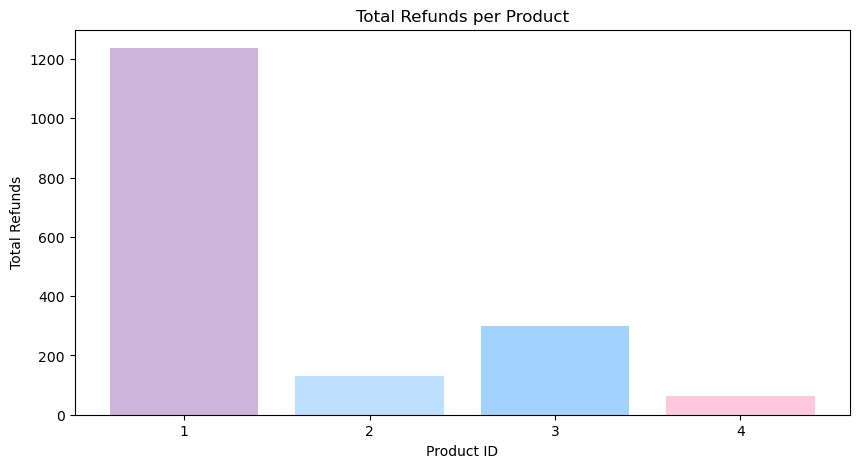

In [101]:
plt.figure(figsize=(10,5))
plt.bar(refund_counts['product_id'].astype(str), refund_counts['total_refunds'],color=['#cdb4db', '#bde0fe', '#a2d2ff', '#ffc8dd'])
plt.xlabel("Product ID")
plt.ylabel("Total Refunds")
plt.title("Total Refunds per Product")
plt.show()

**Insights:**

* Product 1 stands out with the highest number of refunds, far exceeding the others.

* Product 3 has the second-highest refunds, but much lower than Product 1.

* Product 2 has relatively low refunds.

* Product 4 performs best in terms of refunds, with the smallest number recorded

In [102]:
sales_per_product = order_items.groupby('product_id')['price_usd'].sum().reset_index()
sales_per_product.columns = ['product_id', 'sales_revenue']
sales_per_product 

,product_id,sales_revenue
0,1,1211057.74
1,2,347702.04
2,3,229260.15
3,4,150489.82


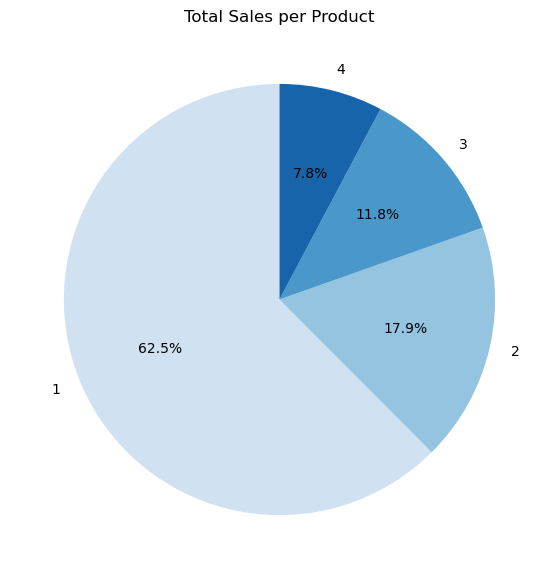

In [105]:
import seaborn as snsrefund_per_product = refunds_items.groupby('product_id')['refund_amount_usd'].sum().reset_index()
colors = sns.color_palette("Blues", len(sales_per_product))
plt.figure(figsize=(7,7))
plt.pie(sales_per_product['sales_revenue'],labels=sales_per_product['product_id'].astype(str),autopct='%1.1f%%',startangle=90,colors=colors)
plt.title("Total Sales per Product")
plt.show()

**Insights:**
* Product 1 dominates sales with 62.5% share.

* Product 2 contributes moderately (17.9%).

* Products 3 and 4 have smaller shares (11.8% and 7.8%).

* Sales are heavily dependent on Product 1.

In [106]:
refund_per_product = refunds_items.groupby('product_id')['refund_amount_usd'].sum().reset_index()

In [107]:
refund_per_product

,product_id,refund_amount_usd
0,1,61837.63
1,2,7738.71
2,3,13842.99
3,4,1919.36


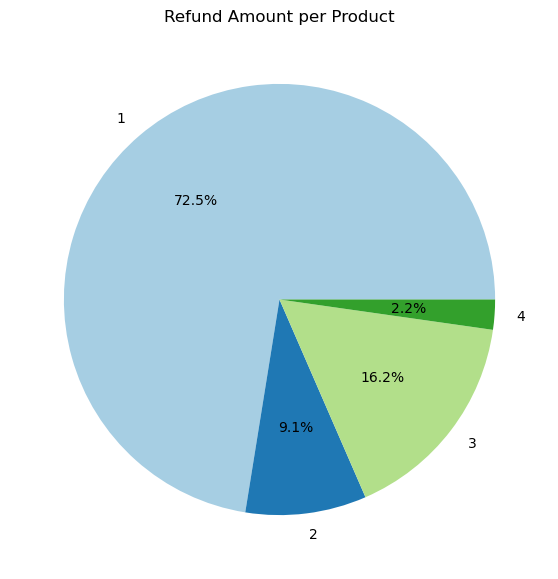

In [108]:
plt.figure(figsize=(7,7))

plt.pie(
    refund_per_product['refund_amount_usd'],
    labels=refund_per_product['product_id'].astype(str),
    autopct='%1.1f%%',
    colors=sns.color_palette("Paired", len(refund_per_product))
)

plt.title("Refund Amount per Product")
plt.show()

**Insights:**

* Product 1 accounts for the majority of refunds (72.5%).

* Product 3 has moderate refunds (16.2%).

* Product 2 contributes a smaller share (9.1%).

* Product 4 has the lowest refund percentage (2.2%).

In [109]:
prod_info=pd.merge(sales_per_product,refund_per_product,on='product_id')

In [110]:
prod_info

,product_id,sales_revenue,refund_amount_usd
0,1,1211057.74,61837.63
1,2,347702.04,7738.71
2,3,229260.15,13842.99
3,4,150489.82,1919.36


In [111]:
prod_info['net_revenue'] = prod_info['sales_revenue'] - prod_info['refund_amount_usd']

In [112]:
prod_info

,product_id,sales_revenue,refund_amount_usd,net_revenue
0,1,1211057.74,61837.63,1149220.11
1,2,347702.04,7738.71,339963.33
2,3,229260.15,13842.99,215417.16
3,4,150489.82,1919.36,148570.46


## TOTAL NET REVENUE

In [113]:
prod_info['net_revenue'].sum() #overall sales revenue

np.float64(1853171.06)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19256\4035250250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=prod_info, x='product_id', y='net_revenue', palette='summer')


NameError: name 'mtick' is not defined

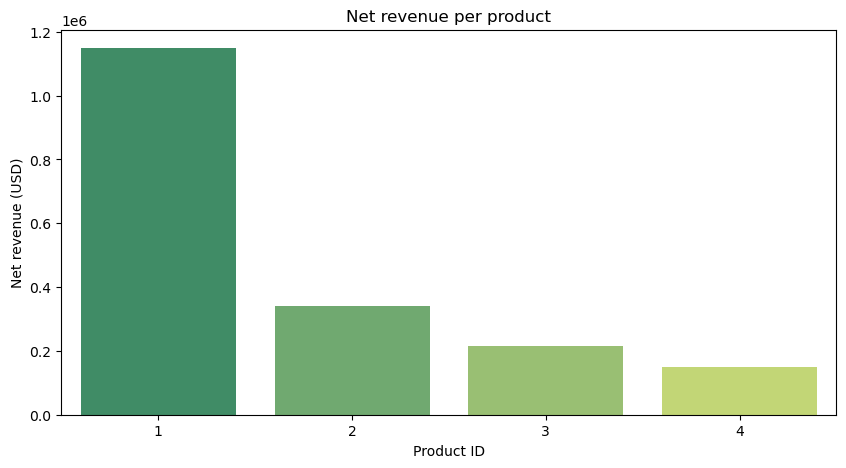

In [131]:
plt.figure(figsize=(10,5))
sns.barplot( data=prod_info, x='product_id', y='net_revenue', palette='summer')
plt.xlabel("Product ID")
plt.ylabel("Net revenue (USD)")
plt.title("Net revenue per product")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

**Insights:**

* Product 1 generates the highest net revenue (1.15M), dominating overall earnings.

* Product 2 is a distant second (340K).

* Product 3 (220K) and Product 4 (150K) contribute significantly less.

* Revenue is heavily concentrated in Product 1.

* Product 1 is the main profit driver for the business.

## CUSTOMER LIFECYCLE ANALYSIS

In [80]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [49]:
customer_orders = orders.groupby('user_id')['order_id'].count().reset_index()
customer_orders.columns = ['user_id', 'total_orders']
#We first count how many orders each customer placed.

In [50]:
customer_orders

,user_id,total_orders
0,13,1
1,20,1
2,59,1
3,104,1
4,147,1
...,...,...
31691,394231,1
31692,394255,1
31693,394257,1
31694,394268,1


In [51]:
customer_orders['total_orders'].unique()

array([1, 2, 3])

In [52]:
customer_orders['customer_type'] = 'New'
customer_orders.loc[customer_orders['total_orders'] > 1, 'customer_type'] = 'Repeat'
#to know the repeat customer according to the number of order placed by them 

In [53]:
customer_orders

,user_id,total_orders,customer_type
0,13,1,New
1,20,1,New
2,59,1,New
3,104,1,New
4,147,1,New
...,...,...,...
31691,394231,1,New
31692,394255,1,New
31693,394257,1,New
31694,394268,1,New


In [54]:
customer_orders['customer_type'].unique()

array(['New', 'Repeat'], dtype=object)

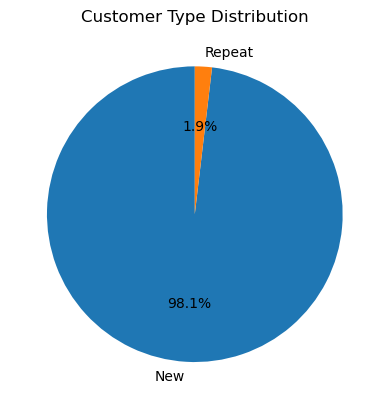

In [55]:
a= customer_orders['customer_type'].value_counts(normalize=True) * 100
plt.figure()
plt.pie(a,labels=a.index,autopct='%1.1f%%',startangle=90)
plt.title('Customer Type Distribution')
plt.show()

**Insights:**

* 98.1% of customers are new customers.

* Only 1.9% are repeat customers.

* Very low customer retention rate.

* The business is attracting new customers but needs to improve repeat purchases and customer loyalty.

## OVERALL TREND

In [56]:
orders["created_at"] = pd.to_datetime(orders["created_at"])

In [57]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [58]:
orders['created_at'].dt.year.unique()


array([2012, 2013, 2014, 2015], dtype=int32)

In [59]:
yearly_orders = orders.groupby(orders['created_at'].dt.year).size().reset_index(name="Sales_per_year")
yearly_orders

,created_at,Sales_per_year
0,2012,2586
1,2013,7447
2,2014,16860
3,2015,5420


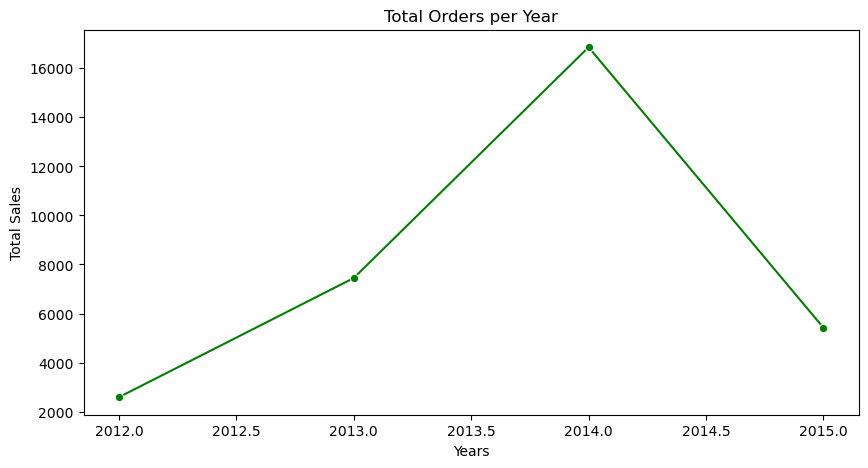

In [60]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_orders, x='created_at', y='Sales_per_year', marker='o',color='green')
plt.xlabel("Years")
plt.ylabel("Total Sales")
plt.title("Total Orders per Year")
plt.show()


**Insights:**

* Orders rose consistently from 2012 to 2014

* 2014 recorded the highest number of orders

* Sharp decline observed in 2015

* 2012 had the lowest order volume

* Overall trend shows growth followed by a sudden drop

In [61]:
Monthly_orders = orders.groupby(orders['created_at'].dt.month).size().reset_index(name="Orders_per_Month")
Monthly_orders

,created_at,Orders_per_Month
0,1,3470
1,2,3587
2,3,2765
3,4,1893
4,5,2047
5,6,1972
6,7,2059
7,8,2161
8,9,2340
9,10,2688


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\3944882187.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




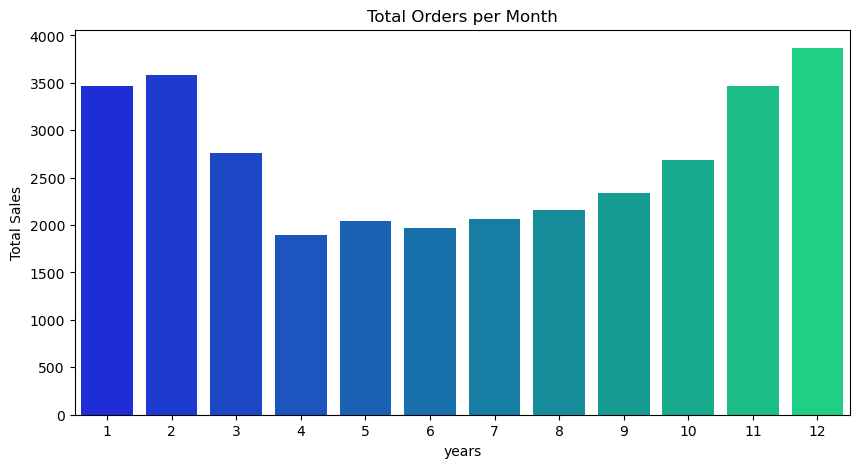

In [62]:
plt.figure(figsize=(10,5))
sns.barplot(data=Monthly_orders,x='created_at',y='Orders_per_Month',palette='winter')
plt.xlabel("years")
plt.ylabel("Total Sales")
plt.title("Total Orders per Month")
plt.show()

**Insights:**

* Highest orders recorded in Month 12

* Strong sales performance in Months 1, 2, 11, and 12

* Lowest orders observed in Month 4

* Gradual recovery in sales from Month 5 onwards

* Overall trend shows dip in early mid-year and rise toward year-end

In [63]:
weekly_orders = orders.groupby(orders['created_at'].dt.day_name()).size()
weekly_orders

created_at
Friday       5571
Monday       5662
Saturday     2309
Sunday       2538
Thursday     5414
Tuesday      5320
Wednesday    5499
dtype: int64

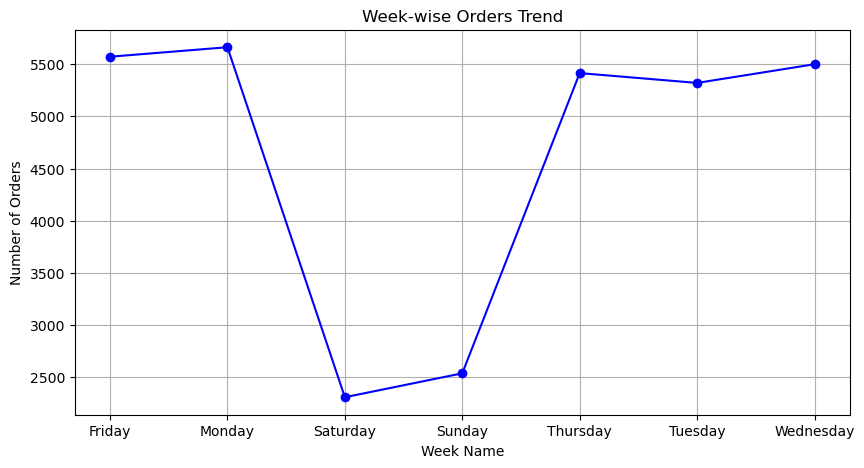

In [64]:
plt.figure(figsize=(10,5))         
plt.plot(weekly_orders, marker='o',color='blue') 
plt.title("Week-wise Orders Trend")
plt.xlabel("Week Name")
plt.ylabel("Number of Orders")
plt.grid(True)                    
plt.show()


**Insights:**

* Highest orders recorded on Monday

* Friday, Wednesday, and Thursday show strong performance

* Lowest orders observed on Saturday

* Slight improvement from Saturday to Sunday

* Weekdays perform significantly better than weekends

In [65]:
hourly_orders = orders.groupby(orders['created_at'].dt.hour).size()
hourly_orders

created_at
0      823
1      721
2      586
3      546
4      549
5      566
6      684
7      756
8     1149
9     1661
10    1948
11    2194
12    2172
13    2085
14    2153
15    2188
16    2099
17    1922
18    1593
19    1378
20    1189
21    1192
22    1131
23    1028
dtype: int64

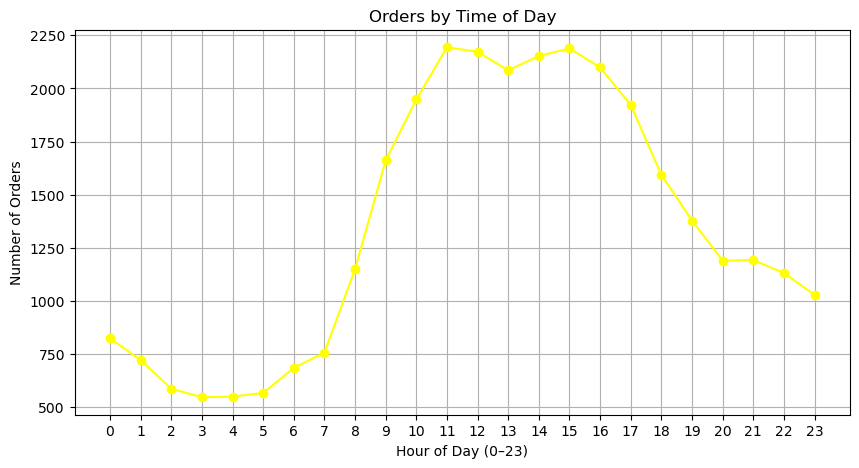

In [66]:
plt.figure(figsize=(10,5))
plt.plot(hourly_orders, marker='o',color='yellow')
plt.title("Orders by Time of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.xticks(range(24))
plt.show()

**Insights:**

* Lowest orders occur during early morning hours (2 AM – 5 AM)

* Orders start increasing steadily after 7 AM

* Peak orders recorded between 11 AM and 3 PM

* Slight decline begins after 4 PM

* Orders gradually decrease during late evening hours

* Midday period is the highest performing time of the day

## REFUND TREND

In [67]:
refunds["created_at"] = pd.to_datetime(refunds["created_at"])

In [68]:
Yearly_Refund_orders = refunds.groupby(refunds['created_at'].dt.year).size().reset_index(name="Refunds_per_Year")
Yearly_Refund_orders

,created_at,Refunds_per_Year
0,2012,169
1,2013,339
2,2014,960
3,2015,263


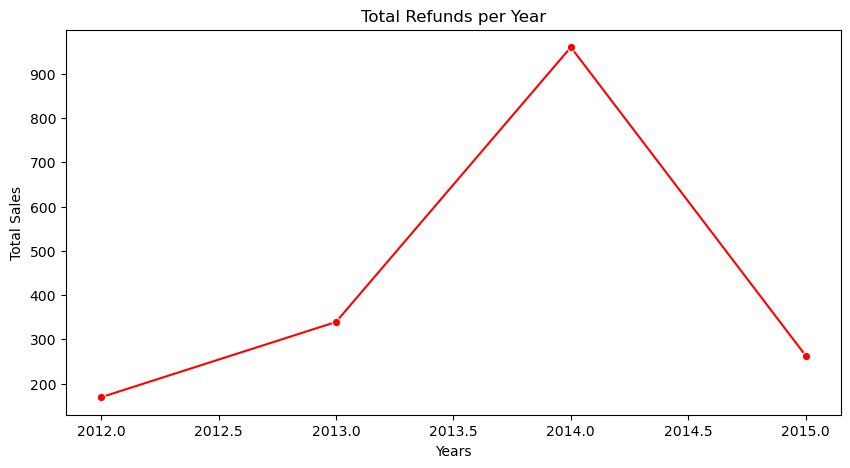

In [69]:
plt.figure(figsize=(10,5))
sns.lineplot(data=Yearly_Refund_orders, x='created_at', y='Refunds_per_Year', marker='o',color='red')
plt.xlabel("Years")
plt.ylabel("Total Sales")
plt.title("Total Refunds per Year")
plt.show()


**Insights:**

* Refunds increased steadily from 2012 to 2014

* 2014 recorded the highest number of refunds

* Significant drop in refunds in 2015

* 2012 had the lowest refund count

* Overall trend shows rise followed by sharp decline

In [70]:
Monthly_Refund_orders = refunds.groupby(refunds['created_at'].dt.to_period('M')).size().reset_index(name="Refunds_per_Month")
Monthly_Refund_orders

,created_at,Refunds_per_Month
0,2012-04,5
1,2012-05,5
2,2012-06,5
3,2012-07,13
4,2012-08,18
5,2012-09,21
6,2012-10,24
7,2012-11,40
8,2012-12,38
9,2013-01,21


In [71]:
Monthly_Refund_orders=refunds.groupby(refunds['created_at'].dt.month).size().reset_index(name="Refunds_per_Month")
Monthly_Refund_orders

,created_at,Refunds_per_Month
0,1,157
1,2,151
2,3,148
3,4,85
4,5,87
5,6,108
6,7,136
7,8,146
8,9,282
9,10,103


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13944\2597038229.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




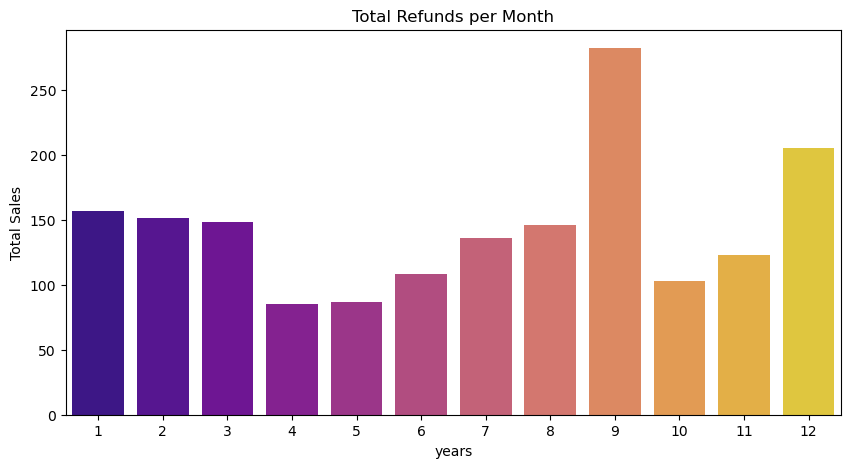

In [72]:
plt.figure(figsize=(10,5))
sns.barplot(data=Monthly_Refund_orders,x='created_at',y='Refunds_per_Month',palette='plasma')
plt.xlabel("years")
plt.ylabel("Total Sales")
plt.title("Total Refunds per Month")
plt.show()

**Insights:**

* Highest refunds recorded in Month 9

* Second highest refunds observed in Month 12

* Lowest refunds in Month 4

* Refunds decrease from Month 1 to Month 4

* Gradual increase from Month 5 to Month 9

* Slight drop after Month 9, then moderate rise toward Month 12
